<a href="https://colab.research.google.com/github/vairagadeshruti355-ctrl/Convex-optimization/blob/main/all_week_code.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

week 1

In [ ]:
# Q1.
import cvxpy as cp
x = cp.Variable()

objective = cp.Minimize((x-2)**2)
problem = cp.Problem(objective)

problem.solve()

print("Optimal Value: ",problem.value)
print("Minimum value: ",x.value)

Optimal Value:  0.0
Minimum value:  2.0


In [ ]:
#Q2.
import cvxpy as cp
x = cp.Variable()

objective = cp.Minimize(x**2)
constraint = [x>=1]

problem = cp.Problem(objective, constraint)
problem.solve()

print("x: ",x.value)

x:  1.0000000000000002


In [ ]:
#Q3.
import cvxpy as cp

x = cp.Variable()
y = cp.Variable()

objective = cp.Minimize(cp.maximum(x, y))
constraints = [2*x + y>=1, x + 3*y >=1, x>=0, y>=0]

problem = cp.Problem(objective, constraints)

problem.solve()

print("a = ",x.value)
print("b = ",y.value)

a =  0.3333333337083394
b =  0.3333333316865374


In [ ]:
# Q4.
import cvxpy as cp
import numpy as np

A = np.random.randn(3,3)
b = np.random.randn(3)

x = cp.Variable(3)
objective = cp.sum_squares(A @ x - b)
problem = cp.Problem(cp.Minimize(objective))
problem.solve()

print("optimal value: ",problem.solve)
print("x: ",x.value)

optimal value:  <bound method Problem.solve of Problem(Minimize(Expression(CONVEX, NONNEGATIVE, ())), [])>
x:  [0.28359011 2.57056267 1.9038129 ]


week 2

In [ ]:
#Q1
import cvxpy as cp
import numpy as np

x, y, z = cp.Variable(3)
objective = cp.Minimize(20*x + 30*y + 10*z)
constraints = [200*x + 150*y + 70*z>=2000, 4*x + 8*y +6*z>=50, 0.5*x + 5*y +5*z <= 60, x>=0,y>=0,z>=0]

problem = cp.Problem(objective, constraints)
problem.solve()

print("servings of rice: ",x.value)
print("servings of milk: ",y.value)
print("number of eggs: ",z.value)

servings of rice:  9.239130423305815
servings of milk:  2.3962437629429875e-08
number of eggs:  2.173913012374572


In [ ]:
#Q2
import cvxpy as cp
import numpy as np

x, y, z = cp.Variable(3)

objective = cp.Minimize(x**2 + 2*y**2 + 3*z**2)
constraints = [x + y + z == 100, x>=0, y>=0, z>=0]

problem = cp.Problem(objective, constraints)
problem.solve()

print("budget allocated to project 1: ",x.value)
print("budget allocated to project 2: ",y.value)
print("budget allocated to project 3: ",z.value)

budget allocated to project 1:  54.54545454545455
budget allocated to project 2:  27.272727272727273
budget allocated to project 3:  18.181818181818183


In [ ]:
#Q3.
import cvxpy as cp
import numpy as np

A = np.array([
    [4, 6, 8, 13, 5, 11, 9, 7, 7, 4, 10, 6]
     ])
x = cp.Variable(12, nonneg = True)
objective = cp.Minimize(x @ A.T)
constraints = [x[0] + x[3] + x[6] + x[9] == 40, x[1] + x[4] +x[7] + x[10] == 50, x[2] + x[5] + x[8] + x[11] == 60]

problem = cp.Problem(objective, constraints)
problem.solve()

print("units: ",problem.value)
print("x: ",x.value)


units:  770.0000002704862
x:  [2.00000000e+01 5.90943185e-09 1.68101534e-08 5.14210379e-09
 5.00000000e+01 9.60036808e-09 7.83239069e-09 1.41310917e-08
 2.78224305e-08 2.00000000e+01 8.28580040e-09 5.99999999e+01]


In [ ]:
#Q4.
import cvxpy as cp
import numpy as np

x = cp.Variable(5)
w = np.array([2, 1, 3, 2, 4])
a = np.array([1.0, 0.8, 1.2, 0.5, 1.5])

objective = cp.Minimize(cp.sum(-w @ cp.log(1 + cp.multiply(a, x))))
constraints = [cp.sum(x) <= 10, x >= 0]

problem = cp.Problem(objective, constraints)
problem.solve()

print("Optimal x: ",x.value)

Optimal x:  [1.62498242 0.06264907 3.10404478 0.62493805 4.58338563]


week 3


In [ ]:
#Q1  DCP problem
import cvxpy as cp

x = cp.Variable()
y = cp.Variable()

prob1 = cp.Problem(cp.Minimize(cp.square(x-y)), [x + y >= 0])
prob2 = cp.Problem(cp.Maximize(cp.sqrt(x-y)), [2*x - 3 == y, cp.square(x) <= 2])

print("prob1 is DCP: ",prob1.is_dcp())
print("prob2 is DCP: ",prob2.is_dcp())


prob1 is DCP:  True
prob2 is DCP:  True


In [ ]:
#Q2 NON-DCP problem
obj = cp.Maximize(cp.square(x))
prob3 =cp.Problem(obj)

print("prob3 is dcp: ",prob3.is_dcp)
print("Maximize(square(x)) is dcp: ",obj.is_dcp())

prob3 is dcp:  <bound method Problem.is_dcp of Problem(Maximize(Expression(CONVEX, NONNEGATIVE, ())), [])>
Maximize(square(x)) is dcp:  False


In [ ]:
#Q3 a non-dcp constraint
prob4 = cp.Problem(cp.Minimize(cp.square(x)), [cp.sqrt(x) <= 2])
print(f"prob4 is DCP: {prob4.is_dcp()}")
print(f"sqrt(x) <= 2 is DCP: {(cp.sqrt(x) <= 2).is_dcp()}")

prob4 is DCP: False
sqrt(x) <= 2 is DCP: False


optimal
1.8588377507009815 1.8463705188081911


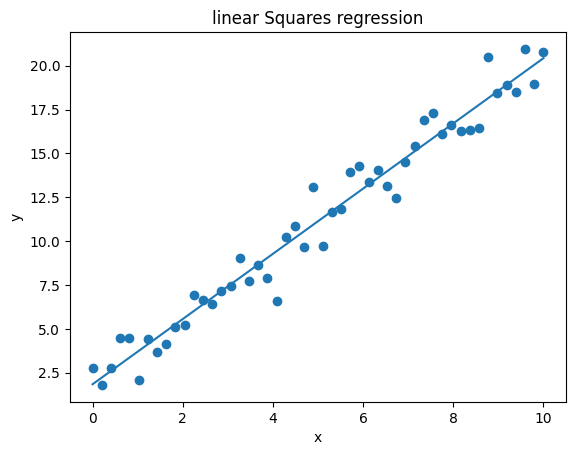

In [ ]:
#Q4 practical convexity

import numpy as np
import cvxpy as cp
import matplotlib.pyplot as plt

np.random.seed(0)

x_data = np.linspace(0,10,50)
y_data = 2*x_data + 1 + np.random.randn(50)

a = cp.Variable()
b = cp.Variable()

objective = cp.Minimize(cp.sum_squares(a*x_data + b - y_data))

problem = cp.Problem(objective)
problem.solve()

print(problem.status)
print(a.value, b.value)

plt.scatter(x_data, y_data)
plt.plot(x_data, a.value*x_data + b.value)
plt.xlabel("x")
plt.ylabel("y")
plt.title("linear Squares regression")
plt.show()

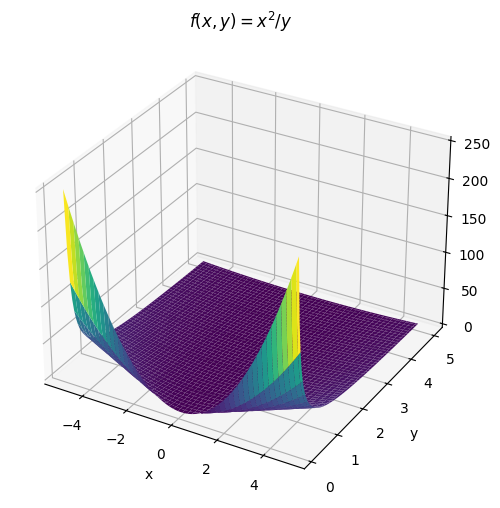

In [ ]:
#Q4 creating a 3D graph
import numpy as np
import matplotlib.pyplot as plt

x = np.linspace(-5, 5, 100)
y = np.linspace(0.1, 5, 100)

X, Y = np.meshgrid(x, y)
Z = X**2/Y

fig = plt.figure(figsize = (8,6))
ax = fig.add_subplot(111, projection = '3d')

ax.plot_surface(X, Y, Z, cmap = 'viridis')
ax.set_xlabel('x')
ax.set_ylabel('y')
#ax.set_zlable('z')
ax.set_title(r'$f(x, y) = x^2/y$')

plt.show()

week 4

In [6]:
# Q1 ridge regression
import cvxpy as cp
import numpy as np
X = np.array([
    [1, 2, 3, 4, 5],
    [2, 1, 0, 1, 2],
    [3, 2, 1, 0, 1],
    [1, 1, 1, 1, 1]
])
beta = cp.Variable(5)
y = np.array([10, 5, 6, 4])
lam = 0.5

objective = cp.Minimize(cp.sum_squares(X @ beta.T - y) + lam*cp.sum_squares(beta))
problem = cp.Problem(objective)

problem.solve()
print("ans: ",problem.value)


ans:  1.556692083565805


In [4]:
#Q2 LASSO Regression
import cvxpy as cp
import numpy as np
x = cp.Variable(3)
A = np.array([
    [1, 2, 3],
    [2, 1, 0],
    [1, 1, 1],
    [3, 2, 1]
])
b = np.array([10, 5, 4, 8])
lam = 0.5
objective = cp.Minimize(cp.sum_squares(A @ x.T - b) + lam*cp.norm1(x))
problem = cp.Problem(objective)

problem.solve()
print("ans: ",problem.value)





ans:  3.993534482758621


In [7]:
#Q3 sparse regression

import cvxpy as cp
import numpy as np

X = np.array([
    [1 ,2 , 3, 4, 5],
    [2, 1, 0, 1, 2],
    [3, 2, 1, 0, 1]
])
beta = cp.Variable(5)
y = np.array([10, 5, 6])

objective = cp.Minimize(cp.sum_squares(X @ beta.T - y))

constraints = [cp.norm(beta, 1) <= 5]

problem = cp.Problem(objective, constraints)

problem.solve()

print("Ans", problem.value)

Ans 2.8153044896368327e-16
